In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Task-1(Data Cleaning)

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Research_All/House Price.xlsx', sheet_name='house_price')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Initial shape:", df.shape)
display(df.head(7))

Initial shape: (205, 22)


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,GarageType,Neighborhood,HouseStyle,Condition,Exterior,Heating,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice
0,16,8311.0,6,2011,1967,719.0,1802,2,3.0,3,BuiltIn,Mitchel,1Story,Excellent,Cement,Oil,14,0,8,2.50,0.95,254044
1,10,14363.0,8,1965,1959,512.0,2994,1,5.0,3,Attached,CollgCr,1Story,Fair,Vinyl,Gas,60,0,9,5.84,1.05,802116
2,101,15383.0,3,2002,2010,NaN,927,1,3.0,1,NaN,CollgCr,1Story,Fair,Wood,Oil,23,1,7,1.13,1.05,154411
3,133,NaN,5,2020,1963,494.0,1514,3,NaN,3,NaN,Somerst,1Story,Good,Cement,Gas,5,0,10,3.06,1.10,254126
4,69,19216.0,7,1959,2000,NaN,3657,1,1.0,2,NaN,Veenker,1Story,Fair,Vinyl,Gas,66,1,5,7.48,1.20,479015
5,96,9910.0,4,1965,2016,1438.0,2458,1,5.0,3,BuiltIn,Veenker,1.5Fin,Good,Cement,Electric,60,1,9,1.71,1.20,376842
6,160,5811.0,8,1955,1983,1883.0,2490,1,4.0,2,Attached,Veenker,1.5Fin,Good,Brick,Gas,70,1,9,1.32,1.20,409956


In [ ]:
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            205 non-null    int64  
 1   LotArea       191 non-null    float64
 2   OverallQual   205 non-null    int64  
 3   YearBuilt     205 non-null    int64  
 4   YearRemodAdd  205 non-null    int64  
 5   TotalBsmtSF   191 non-null    float64
 6   GrLivArea     205 non-null    int64  
 7   FullBath      205 non-null    int64  
 8   BedroomAbvGr  191 non-null    float64
 9   GarageCars    205 non-null    int64  
 10  GarageType    140 non-null    object 
 11  Neighborhood  205 non-null    object 
 12  HouseStyle    205 non-null    object 
 13  Condition     205 non-null    object 
 14  Exterior      205 non-null    object 
 15  Heating       205 non-null    object 
 16  HouseAge      205 non-null    int64  
 17  Remodeled     205 non-null    int64  
 18  TotalRooms    2

In [ ]:
# Show duplicate rows
dups = df.duplicated()
print("Duplicate rows (boolean sum):", dups.sum())

if dups.sum() > 0:
    print("Example duplicate rows (first 5):")
    display(df[dups].head(5))


Duplicate rows (boolean sum): 5
Example duplicate rows (first 5):


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,GarageType,Neighborhood,HouseStyle,Condition,Exterior,Heating,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice
33,31,13627.0,8,2018,1952,1742.0,2803,3,5.0,1,BuiltIn,Crawfor,2Story,Fair,Cement,Electric,7,0,10,1.61,1.15,433333
82,96,9910.0,4,1965,2016,1438.0,2458,1,5.0,3,BuiltIn,Veenker,1.5Fin,Good,Cement,Electric,60,1,9,1.71,1.20,376842
137,159,18708.0,6,1987,1967,1082.0,3587,1,4.0,1,Attached,Timber,SLvl,Excellent,Brick,Gas,38,0,7,3.31,1.05,772218
172,16,8311.0,6,2011,1967,719.0,1802,2,3.0,3,BuiltIn,Mitchel,1Story,Excellent,Cement,Oil,14,0,8,2.50,0.95,254044
196,129,3663.0,4,1987,1957,723.0,1374,3,3.0,3,Attached,CollgCr,1Story,Good,Cement,Electric,38,0,9,1.90,1.05,218521


In [ ]:
# Remove exact duplicate rows (keep first)
#if dups.sum() > 0:
  #  df = df.drop_duplicates(keep='first').reset_index(drop=True)
   # print("Shape after dropping exact duplicates:", df.shape)
#else:
  #  print("No exact duplicate rows found.")

df = df.drop_duplicates(keep='first').reset_index(drop=True)
print("Shape after dropping exact duplicates:", df.shape)


Shape after dropping exact duplicates: (200, 22)


In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("Missing Value Summary:")
display(missing_summary[missing_summary['Missing Values'] > 0])


Missing Value Summary:


,Missing Values,Percentage (%)
GarageType,65,32.5
LotArea,14,7.0
BedroomAbvGr,14,7.0
TotalBsmtSF,14,7.0


Handle missing values

In [ ]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Filled missing numeric values in '{col}' with median: {median_value}")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Filled missing categorical values in '{col}' with mode: {mode_value}")


Filled missing numeric values in 'LotArea' with median: 11057.0
Filled missing numeric values in 'TotalBsmtSF' with median: 1231.0
Filled missing numeric values in 'BedroomAbvGr' with median: 3.0
Filled missing categorical values in 'GarageType' with mode: Attached


In [ ]:
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            200 non-null    int64  
 1   LotArea       200 non-null    float64
 2   OverallQual   200 non-null    int64  
 3   YearBuilt     200 non-null    int64  
 4   YearRemodAdd  200 non-null    int64  
 5   TotalBsmtSF   200 non-null    float64
 6   GrLivArea     200 non-null    int64  
 7   FullBath      200 non-null    int64  
 8   BedroomAbvGr  200 non-null    float64
 9   GarageCars    200 non-null    int64  
 10  GarageType    200 non-null    object 
 11  Neighborhood  200 non-null    object 
 12  HouseStyle    200 non-null    object 
 13  Condition     200 non-null    object 
 14  Exterior      200 non-null    object 
 15  Heating       200 non-null    object 
 16  HouseAge      200 non-null    int64  
 17  Remodeled     200 non-null    int64  
 18  TotalRooms    2

Check inconsistent years

In [ ]:
# Find columns represent years
year_cols = [c for c in df.columns if 'year' in c.lower() or 'yr' in c.lower()]
print("Likely year columns:", year_cols)


Likely year columns: ['YearBuilt', 'YearRemodAdd']


In [ ]:
from datetime import datetime

CURRENT_YEAR = datetime.now().year
MIN_YEAR = 1800  # adjust if historic houses exist

for col in year_cols:
    if df[col].dtype != 'O':  # numeric columns
        invalid_mask = (df[col] < MIN_YEAR) | (df[col] > CURRENT_YEAR)
        count_invalid = invalid_mask.sum()
        if count_invalid > 0:
            print(f"Column '{col}' has {count_invalid} values outside [{MIN_YEAR}, {CURRENT_YEAR}]")
            df.loc[invalid_mask, col] = np.nan


In [ ]:
if 'YearBuilt' in df.columns and 'YearRemodAdd' in df.columns:
    illogical_mask = df['YearRemodAdd'] < df['YearBuilt']
    count_illogical = illogical_mask.sum()
    print(f"Found {count_illogical} rows where YearRemodAdd < YearBuilt")

    df.loc[illogical_mask, 'YearRemodAdd'] = df.loc[illogical_mask, 'YearBuilt']


Found 99 rows where YearRemodAdd < YearBuilt


In [ ]:
for col in year_cols:
    if col in df.columns:
        df[col] = df[col].round(0).astype('Int64')


In [ ]:
from datetime import datetime

CURRENT_YEAR = datetime.now().year
MIN_YEAR = 1800

year_cols = [c for c in df.columns if 'year' in c.lower() or 'yr' in c.lower()]
print("Year columns detected:", year_cols)

for col in year_cols:
    invalid_mask = (df[col] < MIN_YEAR) | (df[col] > CURRENT_YEAR)
    count_invalid = invalid_mask.sum()
    if count_invalid > 0:
        print(f"⚠ Column '{col}' has {count_invalid} values outside [{MIN_YEAR}, {CURRENT_YEAR}]")
    else:
        print(f"Column '{col}' has all values within a valid range.")

if 'YearBuilt' in df.columns and 'YearRemodAdd' in df.columns:
    illogical_mask = df['YearRemodAdd'] < df['YearBuilt']
    count_illogical = illogical_mask.sum()
    if count_illogical > 0:
        print(f"⚠ Found {count_illogical} rows where YearRemodAdd < YearBuilt")
    else:
        print(f"All YearRemodAdd values are consistent with YearBuilt")


Year columns detected: ['YearBuilt', 'YearRemodAdd']
Column 'YearBuilt' has all values within a valid range.
Column 'YearRemodAdd' has all values within a valid range.
⚠ Found 103 rows where YearRemodAdd < YearBuilt


In [ ]:
cleaned_file_xlsx = 'house_price_cleaned.xlsx'
df.to_excel(cleaned_file_xlsx, index=False)
print(f"Cleaned dataset saved successfully as '{cleaned_file_xlsx}'")


Cleaned dataset saved successfully as 'house_price_cleaned.xlsx'


# Task-2(Perform EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)



In [ ]:
# Summary statistics for numeric columns
display(df.describe())

# Summary for categorical columns
display(df.select_dtypes(exclude=[np.number]).describe())


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice
count,205.000000,191.000000,205.000000,205.000000,205.000000,191.000000,205.000000,205.000000,191.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,2.050000e+02
mean,100.151220,11086.235602,6.009756,1984.414634,1984.595122,1188.701571,2320.682927,1.995122,3.052356,1.560976,40.585366,0.492683,8.000000,2.361073,1.078537,3.352965e+05
std,57.855902,4827.056295,2.019489,20.275765,21.736546,468.159959,1011.704610,0.831356,1.424368,1.125654,20.275765,0.501170,1.852396,1.630625,0.107114,1.308979e+05
min,1.000000,3161.000000,3.000000,1950.000000,1950.000000,400.000000,624.000000,1.000000,1.000000,0.000000,5.000000,0.000000,4.000000,0.320000,0.900000,1.013610e+05
25%,50.000000,6916.500000,4.000000,1966.000000,1966.000000,726.500000,1430.000000,1.000000,2.000000,1.000000,23.000000,0.000000,7.000000,1.290000,1.050000,2.410160e+05
50%,100.000000,11004.000000,6.000000,1984.000000,1983.000000,1227.000000,2359.000000,2.000000,3.000000,2.000000,41.000000,0.000000,8.000000,1.950000,1.050000,3.197130e+05
75%,150.000000,14713.500000,8.000000,2002.000000,2004.000000,1585.000000,3237.000000,3.000000,4.000000,3.000000,59.000000,1.000000,9.000000,2.820000,1.150000,4.166860e+05
max,200.000000,19850.000000,9.000000,2020.000000,2022.000000,1995.000000,3989.000000,3.000000,5.000000,3.000000,75.000000,1.000000,12.000000,8.420000,1.250000,1.002319e+06


,GarageType,Neighborhood,HouseStyle,Condition,Exterior,Heating
count,140,205,205,205,205,205
unique,3,8,4,4,4,3
top,Attached,CollgCr,1Story,Good,Cement,Electric
freq,50,30,53,64,61,76


**Correlations Between Numeric Features**

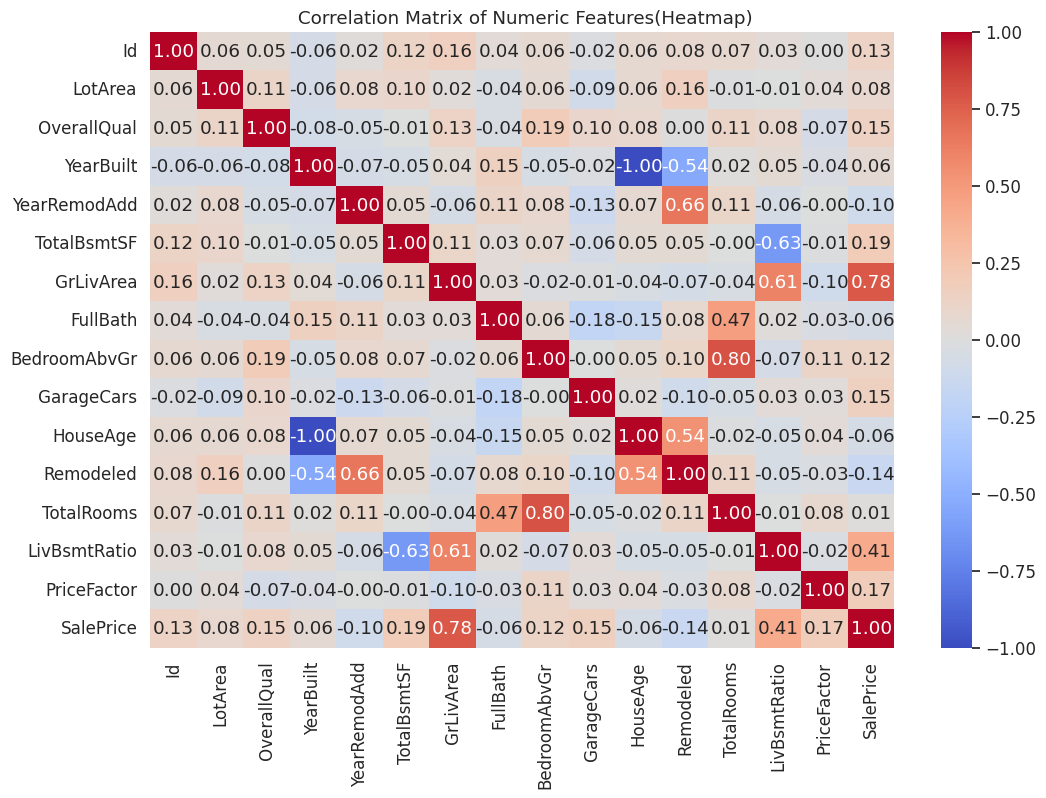

In [ ]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

# correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(" Correlation Matrix of Numeric Features(Heatmap)")
plt.show()

Top Correlations with SalePrice

In [ ]:
corr_target = corr['SalePrice'].sort_values(ascending=False)
print("Top features correlated with SalePrice:")
print(corr_target)

Top features correlated with SalePrice:
SalePrice       1.000000
GrLivArea       0.778299
LivBsmtRatio    0.409631
TotalBsmtSF     0.189573
PriceFactor     0.174776
GarageCars      0.151074
OverallQual     0.146541
Id              0.128504
BedroomAbvGr    0.120108
LotArea         0.078322
YearBuilt       0.056271
TotalRooms      0.010626
HouseAge       -0.056271
FullBath       -0.062321
YearRemodAdd   -0.100986
Remodeled      -0.140763
Name: SalePrice, dtype: float64


Select Numeric Columns

In [ ]:
# Select all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns in dataset:", numeric_cols)


Numeric columns in dataset: ['Id', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 'GrLivArea', 'FullBath', 'BedroomAbvGr', 'GarageCars', 'HouseAge', 'Remodeled', 'TotalRooms', 'LivBsmtRatio', 'PriceFactor', 'SalePrice']


**Plot Distributions**, Helps visually see if the data is normal (bell-shaped) or skewed.
This shows how each numeric feature is distributed, helping identify skewed or abnormal features.

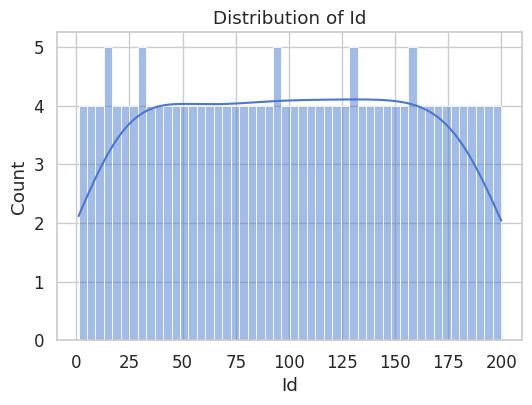

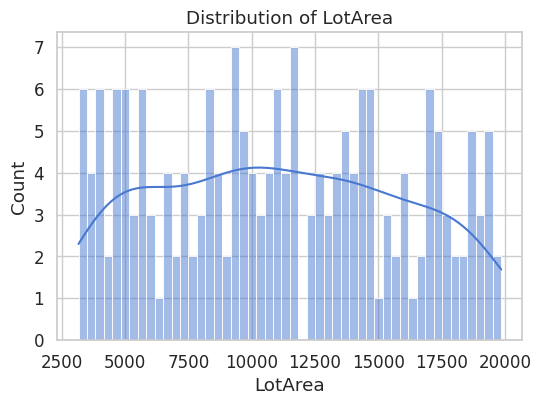

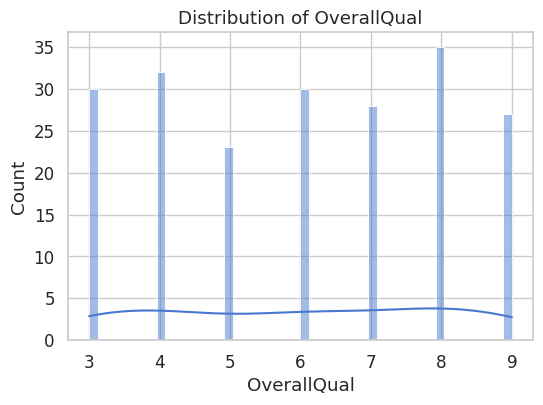

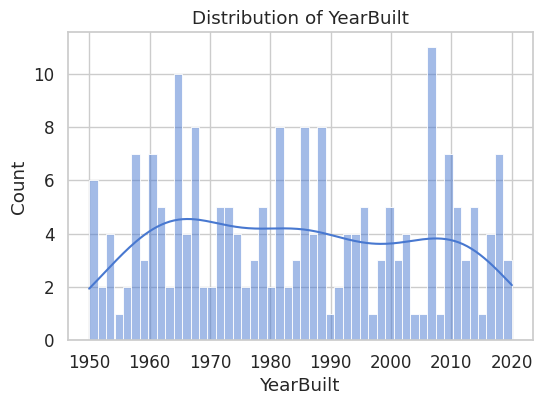

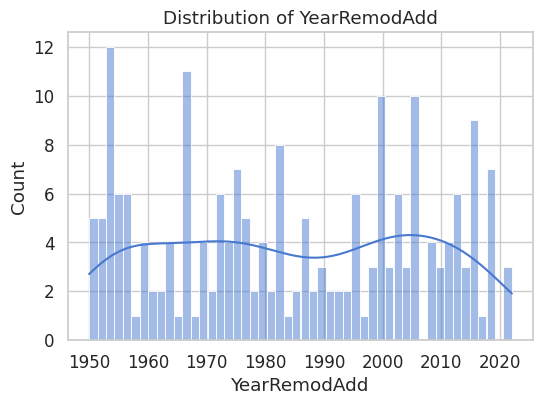

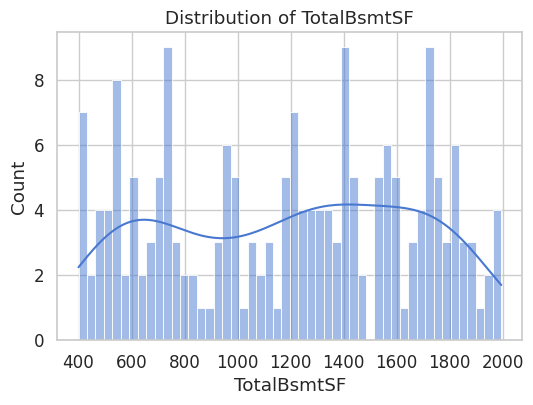

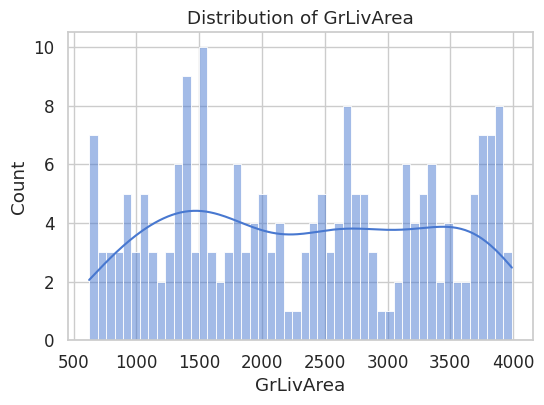

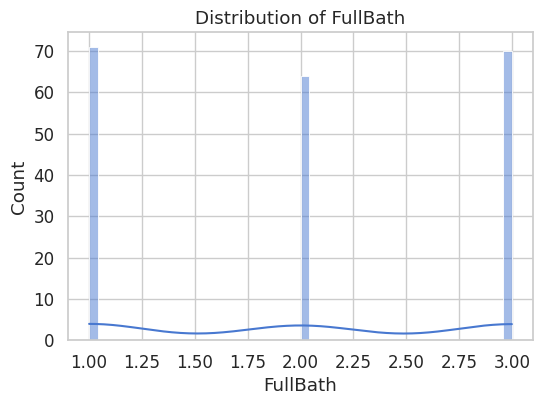

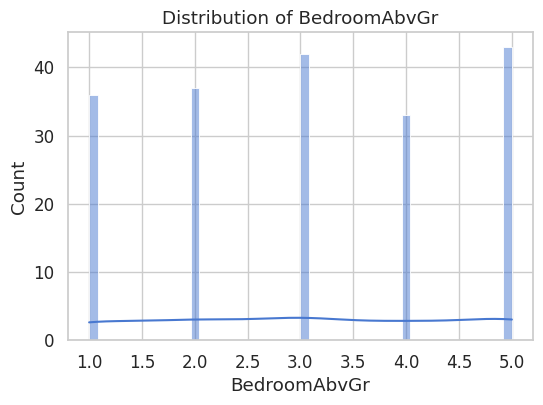

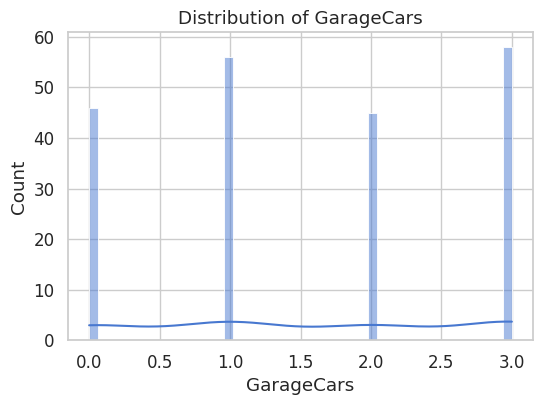

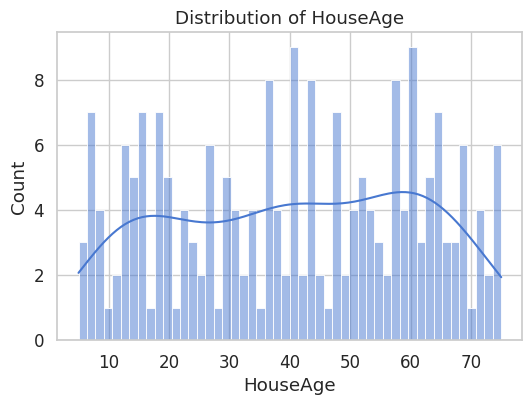

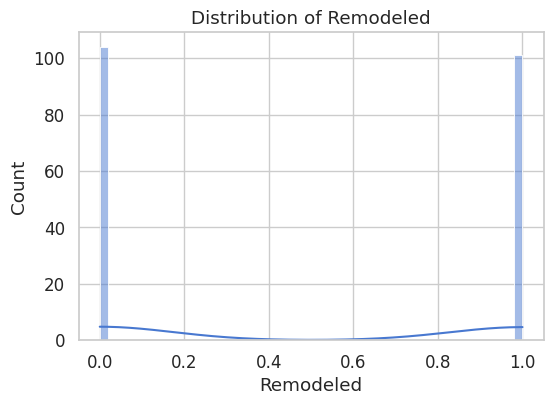

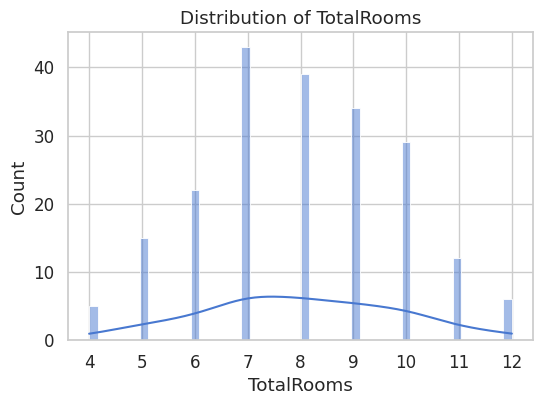

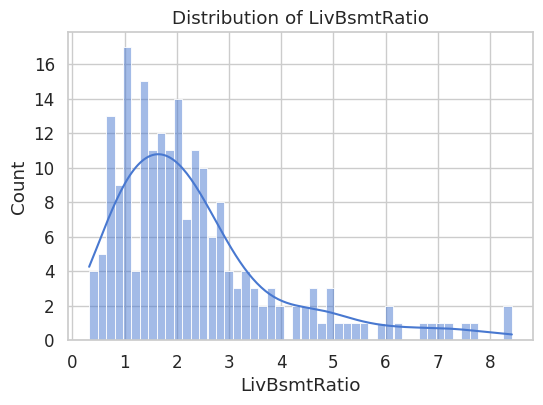

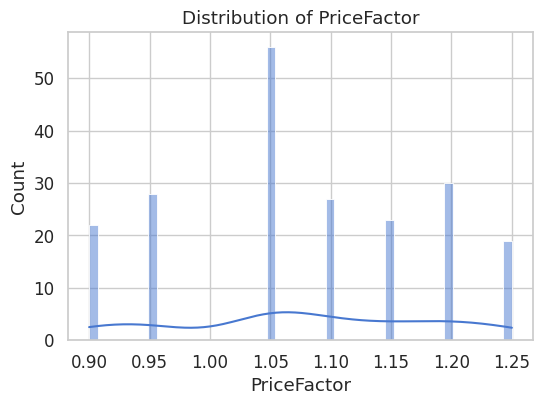

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')  # Exclude target

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)  # Histogram + KDE
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()





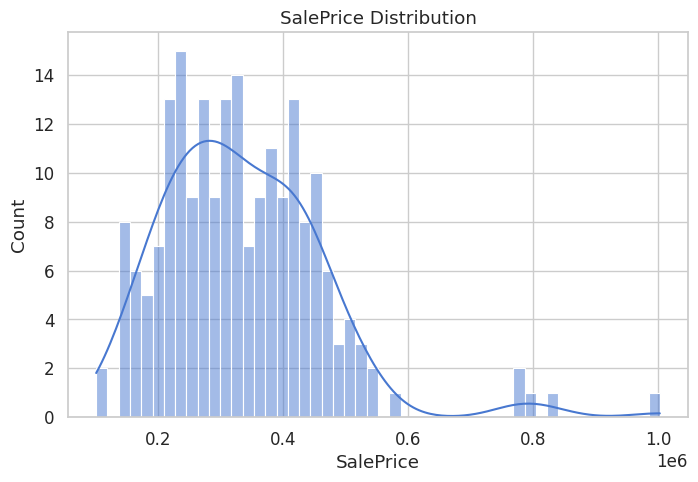

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()


Skewness tells you how  "uneven" your data distribution is.

Skewness ≈ 0 → "Normal/Balanced Distribution",
Skewness > 0 → "Right-Skewed" (Positive Skew),
 Skewness < 0 → "Left-Skewed" (Negative Skew)

In [ ]:
# Compute skewness for numeric columns
skew_values = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numeric columns:")
print(skew_values)


Skewness of numeric columns:
LivBsmtRatio    1.585583
YearBuilt       0.091027
LotArea         0.068419
GrLivArea       0.036826
Remodeled       0.029488
TotalRooms      0.023364
FullBath        0.009161
YearRemodAdd    0.002197
Id             -0.000033
BedroomAbvGr   -0.015780
GarageCars     -0.028480
OverallQual    -0.045890
TotalBsmtSF    -0.090912
HouseAge       -0.091027
PriceFactor    -0.111833
dtype: float64


Outliers detection

In [ ]:
df_out = df.copy()

In [ ]:
outliers_summary = {}

for col in numeric_cols:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_out[(df[col] < lower_bound) | (df_out[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

    print(f"{col}: {len(outliers)} outliers")
df_out.head()
#df.head()
#df.head()

Id: 0 outliers
LotArea: 0 outliers
OverallQual: 0 outliers
YearBuilt: 0 outliers
YearRemodAdd: 0 outliers
TotalBsmtSF: 0 outliers
GrLivArea: 0 outliers
FullBath: 0 outliers
BedroomAbvGr: 0 outliers
GarageCars: 0 outliers
HouseAge: 0 outliers
Remodeled: 0 outliers
TotalRooms: 0 outliers
LivBsmtRatio: 15 outliers
PriceFactor: 22 outliers


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,GarageType,Neighborhood,HouseStyle,Condition,Exterior,Heating,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice
0,16,8311.0,6,2011,1967,719.0,1802,2,3.0,3,BuiltIn,Mitchel,1Story,Excellent,Cement,Oil,14,0,8,2.50,0.95,254044
1,10,14363.0,8,1965,1959,512.0,2994,1,5.0,3,Attached,CollgCr,1Story,Fair,Vinyl,Gas,60,0,9,5.84,1.05,802116
2,101,15383.0,3,2002,2010,NaN,927,1,3.0,1,NaN,CollgCr,1Story,Fair,Wood,Oil,23,1,7,1.13,1.05,154411
3,133,NaN,5,2020,1963,494.0,1514,3,NaN,3,NaN,Somerst,1Story,Good,Cement,Gas,5,0,10,3.06,1.10,254126
4,69,19216.0,7,1959,2000,NaN,3657,1,1.0,2,NaN,Veenker,1Story,Fair,Vinyl,Gas,66,1,5,7.48,1.20,479015


Show all outliers

In [ ]:
outliers_details = pd.DataFrame()

for col in numeric_cols:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    mask = (df_out[col] < lower_bound) | (df_out[col] > upper_bound)

    # Add column to mark outliers
    df_out[f'{col}_outlier'] = mask

    # Save outlier rows
    outliers = df_out[mask].copy()
    if not outliers.empty:
        outliers['Outlier_Column'] = col
        outliers_details = pd.concat([outliers_details, outliers])

# Remove duplicates if a row is an outlier in multiple columns
outliers_details = outliers_details.drop_duplicates()
print(f"Total outlier rows detected: {len(outliers_details)}")
display(outliers_details)


Total outlier rows detected: 37


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,GarageType,Neighborhood,HouseStyle,Condition,Exterior,Heating,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice,Id_outlier,LotArea_outlier,OverallQual_outlier,YearBuilt_outlier,YearRemodAdd_outlier,TotalBsmtSF_outlier,GrLivArea_outlier,FullBath_outlier,BedroomAbvGr_outlier,GarageCars_outlier,HouseAge_outlier,Remodeled_outlier,TotalRooms_outlier,LivBsmtRatio_outlier,Outlier_Column,PriceFactor_outlier
1,10,14363.0,8,1965,1959,512.0,2994,1,5.0,3,Attached,CollgCr,1Story,Fair,Vinyl,Gas,60,0,9,5.84,1.05,802116,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
4,69,19216.0,7,1959,2000,NaN,3657,1,1.0,2,NaN,Veenker,1Story,Fair,Vinyl,Gas,66,1,5,7.48,1.20,479015,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
12,66,10208.0,7,1985,1987,531.0,3237,2,5.0,2,NaN,Veenker,2Story,Good,Wood,Electric,40,1,10,6.08,1.20,446335,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
18,87,14837.0,5,1968,1992,503.0,2809,1,3.0,0,NaN,Timber,SLvl,Good,Brick,Gas,57,1,6,5.57,1.05,310552,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
21,102,17820.0,5,1972,2000,556.0,3725,1,2.0,1,NaN,CollgCr,2Story,Average,Cement,Electric,53,1,6,6.69,1.05,409312,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
42,112,19312.0,7,1984,1954,595.0,3749,2,3.0,1,Attached,NoRidge,1.5Fin,Good,Vinyl,Gas,41,0,8,6.29,1.25,509921,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
47,140,3854.0,4,2010,1956,410.0,3462,3,2.0,0,NaN,Somerst,1Story,Fair,Cement,Oil,15,0,8,8.42,1.10,392874,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
75,167,4734.0,6,1996,1975,526.0,3829,2,2.0,2,Attached,NAmes,SLvl,Fair,Vinyl,Electric,29,0,8,7.27,0.90,384008,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
90,139,16877.0,8,1968,2005,468.0,2520,3,4.0,0,Attached,Veenker,1.5Fin,Excellent,Wood,Electric,57,1,11,5.37,1.20,343763,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN
112,11,19023.0,5,2000,2005,539.0,3287,3,1.0,3,Attached,Crawfor,1Story,Good,Cement,Gas,25,1,8,6.09,1.15,437894,False,False,False,False,False,False,False,False,False,False,False,False,False,True,LivBsmtRatio,NaN


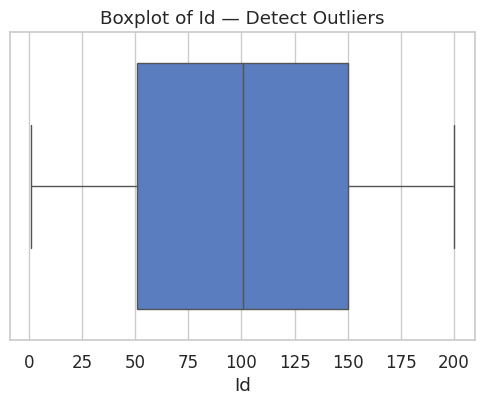

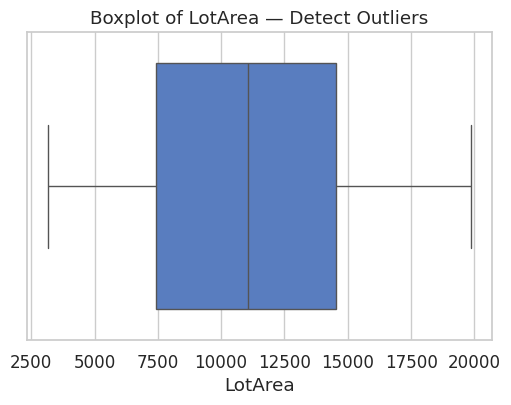

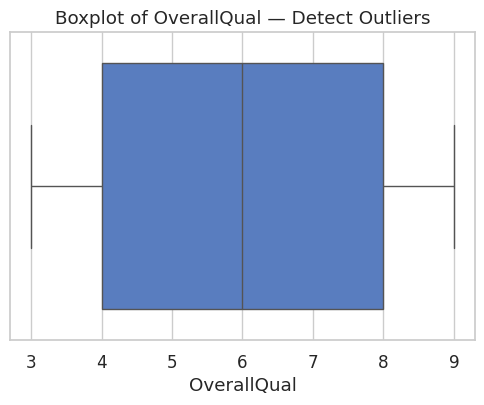

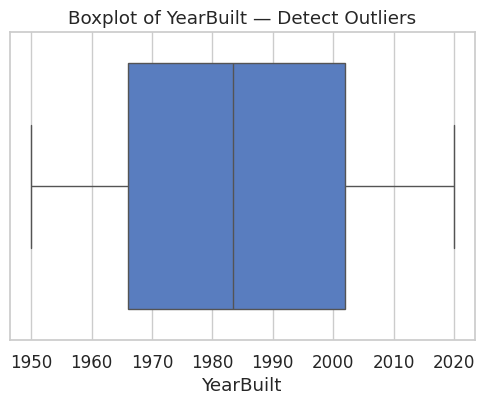

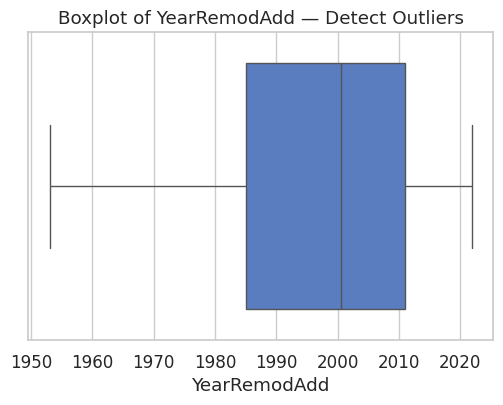

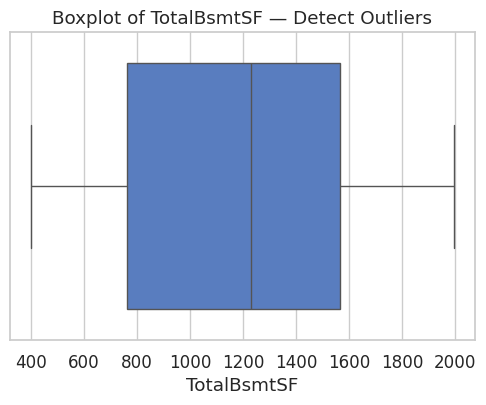

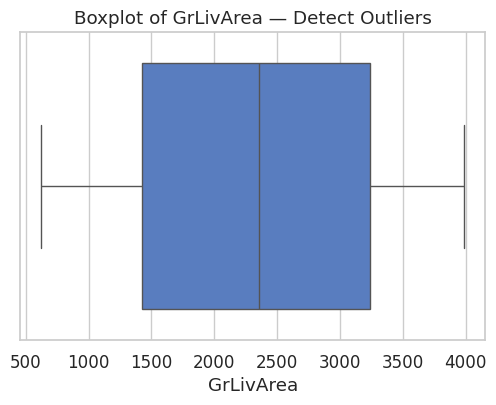

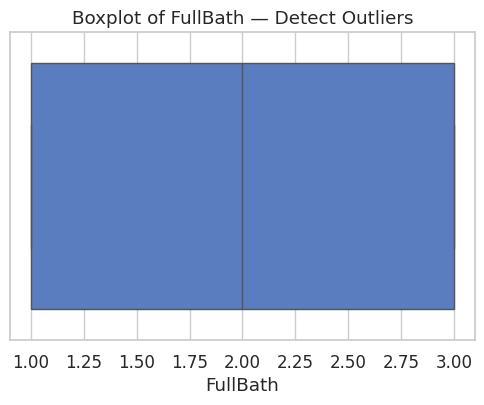

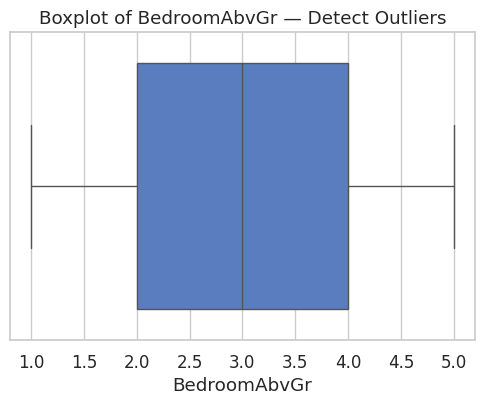

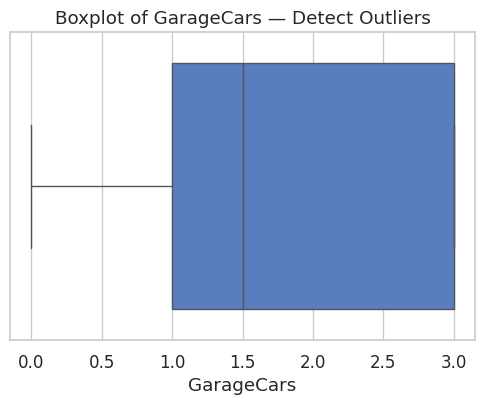

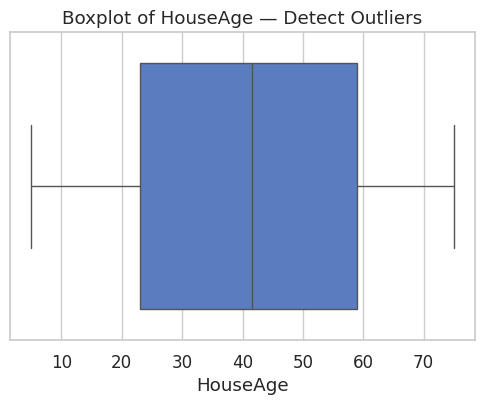

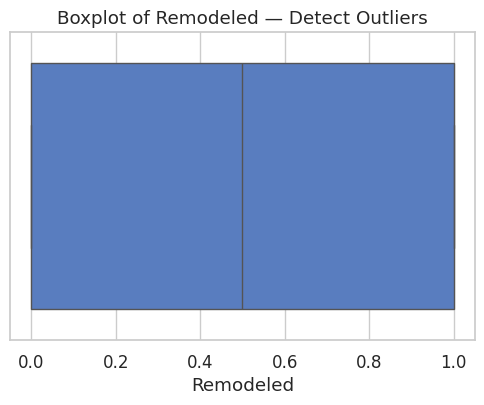

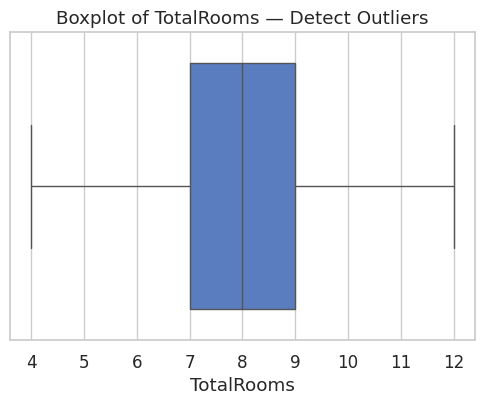

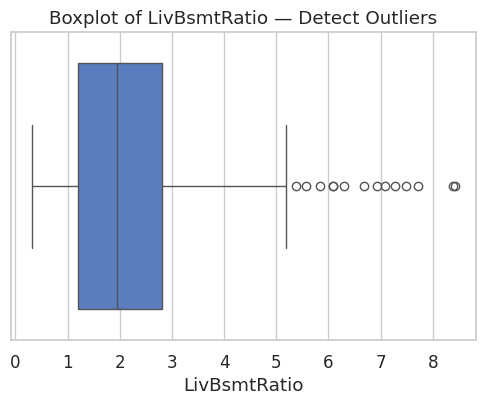

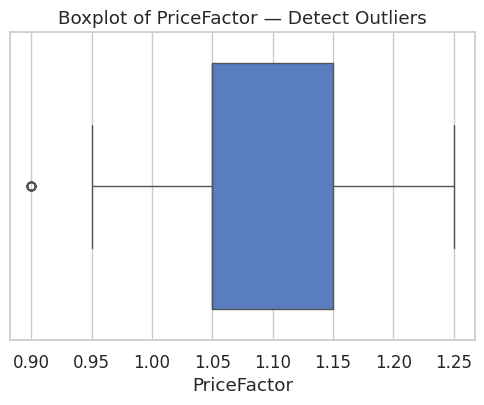

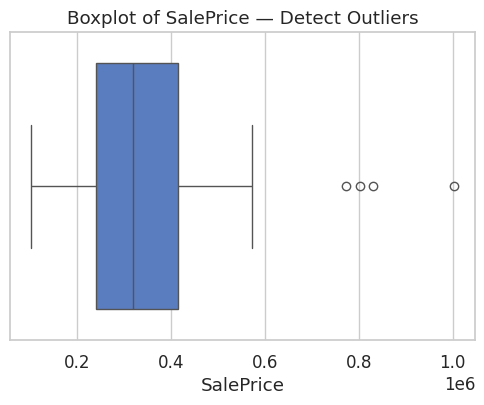

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_out[col])
    plt.title(f"Boxplot of {col} — Detect Outliers")
    plt.show()


Boxplots show outliers clearly (points outside whiskers).

Visualizes scatterplots between features and target.

Helps to identify linear or non-linear trends.

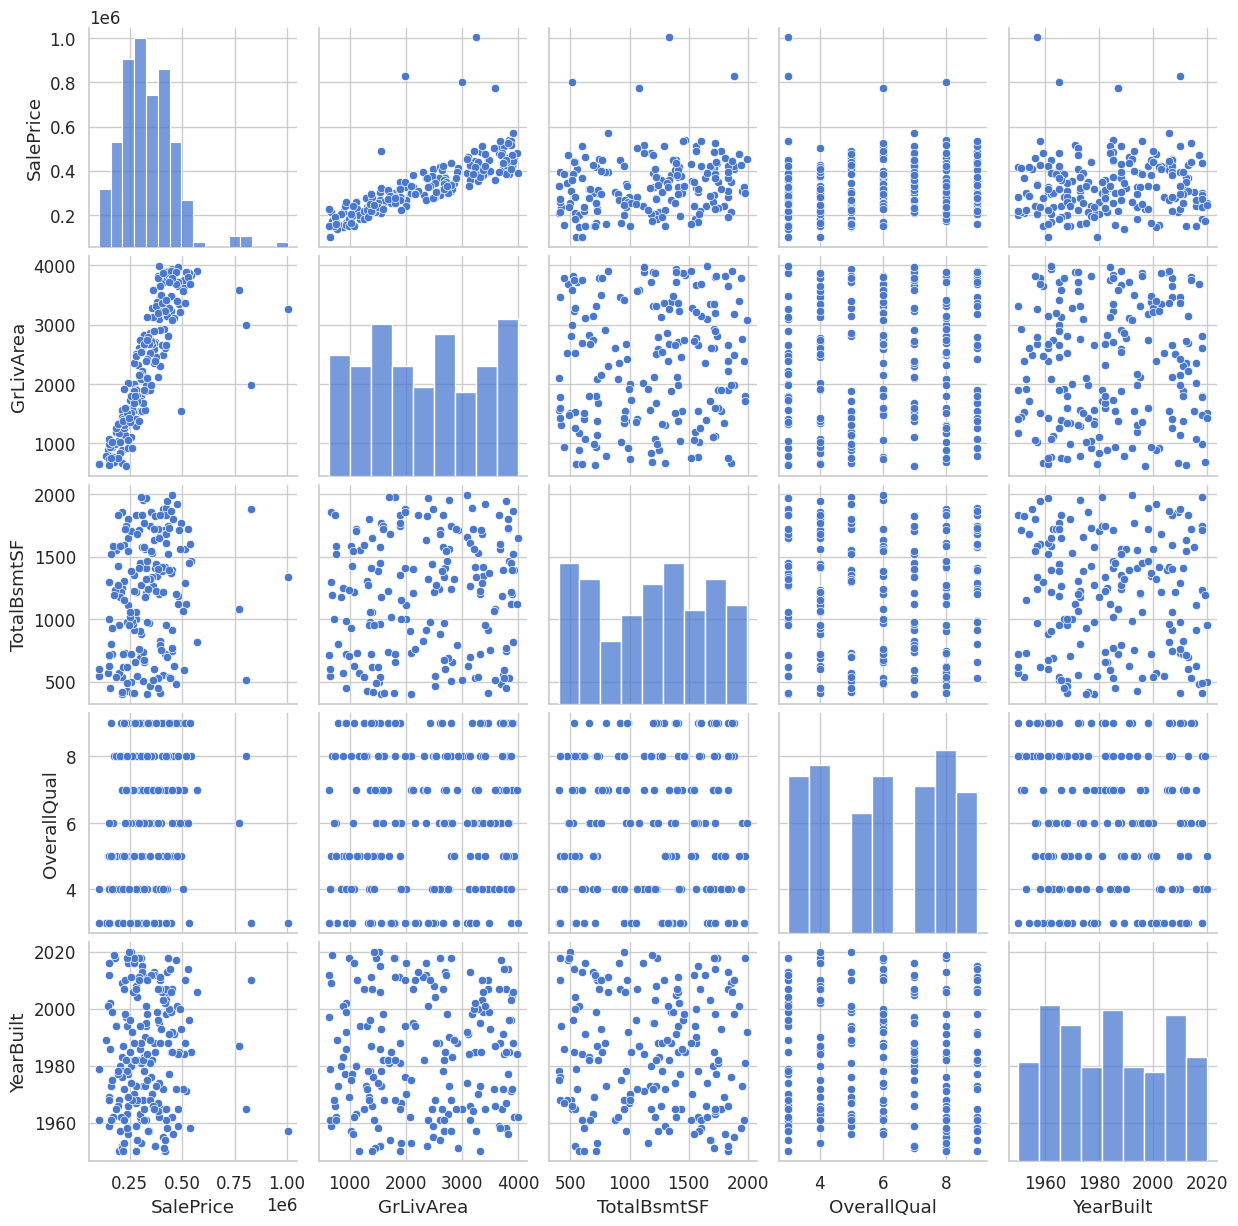

In [ ]:
subset_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt']

sns.pairplot(df_out[subset_cols])
plt.show()


In [ ]:
df.head()

,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,GarageType,Neighborhood,HouseStyle,Condition,Exterior,Heating,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice
0,16,8311.0,6,2011,1967,719.0,1802,2,3.0,3,BuiltIn,Mitchel,1Story,Excellent,Cement,Oil,14,0,8,2.50,0.95,254044
1,10,14363.0,8,1965,1959,512.0,2994,1,5.0,3,Attached,CollgCr,1Story,Fair,Vinyl,Gas,60,0,9,5.84,1.05,802116
2,101,15383.0,3,2002,2010,NaN,927,1,3.0,1,NaN,CollgCr,1Story,Fair,Wood,Oil,23,1,7,1.13,1.05,154411
3,133,NaN,5,2020,1963,494.0,1514,3,NaN,3,NaN,Somerst,1Story,Good,Cement,Gas,5,0,10,3.06,1.10,254126
4,69,19216.0,7,1959,2000,NaN,3657,1,1.0,2,NaN,Veenker,1Story,Fair,Vinyl,Gas,66,1,5,7.48,1.20,479015


# Task-3(Feature Engineering)

Label encoding categorial variables(convert text labels into numeric codes)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Ordinal columns to Label Encoding
ordinal_cols = ['OverallQual', 'Condition']
le_dict = {}
for col in ordinal_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Nominal columns to One-Hot Encoding
nominal_cols = ['GarageType', 'Neighborhood', 'HouseStyle', 'Exterior', 'Heating']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)

pd.set_option('display.max_columns', None)  # Show all columns
display(df_encoded.head(15))


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,Condition,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice,GarageType_BuiltIn,GarageType_Detached,Neighborhood_Crawfor,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NoRidge,Neighborhood_Somerst,Neighborhood_Timber,Neighborhood_Veenker,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_SLvl,Exterior_Cement,Exterior_Vinyl,Exterior_Wood,Heating_Gas,Heating_Oil
0,16,8311.0,3,2011,1967,719.0,1802,2,3.0,3,1,14,0,8,2.50,0.95,254044,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True
1,10,14363.0,5,1965,1959,512.0,2994,1,5.0,3,2,60,0,9,5.84,1.05,802116,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,101,15383.0,0,2002,2010,1231.0,927,1,3.0,1,2,23,1,7,1.13,1.05,154411,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True
3,133,11057.0,2,2020,1963,494.0,1514,3,3.0,3,3,5,0,10,3.06,1.10,254126,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False
4,69,19216.0,4,1959,2000,1231.0,3657,1,1.0,2,2,66,1,5,7.48,1.20,479015,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,True,False
5,96,9910.0,1,1965,2016,1438.0,2458,1,5.0,3,3,60,1,9,1.71,1.20,376842,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
6,160,5811.0,5,1955,1983,1883.0,2490,1,4.0,2,3,70,1,9,1.32,1.20,409956,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
7,163,4986.0,5,1994,1991,1407.0,1987,1,3.0,3,0,31,0,7,1.41,1.05,327151,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
8,148,11057.0,5,2007,1988,745.0,3790,3,5.0,1,1,18,0,10,5.08,1.05,452059,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
9,183,11057.0,4,2006,2004,819.0,3906,2,1.0,3,0,19,0,5,4.76,1.25,572583,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
print("\nDataset info:")
print(df_encoded.info())
print("\nMissing values:")
print(df_encoded.isnull().sum())
print("\nDuplicate rows:", df_encoded.duplicated().sum())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    200 non-null    int64  
 1   LotArea               200 non-null    float64
 2   OverallQual           200 non-null    int64  
 3   YearBuilt             200 non-null    int64  
 4   YearRemodAdd          200 non-null    int64  
 5   TotalBsmtSF           200 non-null    float64
 6   GrLivArea             200 non-null    int64  
 7   FullBath              200 non-null    int64  
 8   BedroomAbvGr          200 non-null    float64
 9   GarageCars            200 non-null    int64  
 10  Condition             200 non-null    int64  
 11  HouseAge              200 non-null    int64  
 12  Remodeled             200 non-null    int64  
 13  TotalRooms            200 non-null    int64  
 14  LivBsmtRatio          200 non-null    float64
 15  PriceFac

Hanldle missing value

In [ ]:


numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
categorical_cols = df_encoded.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    if df_encoded[col].isnull().sum() > 0:
        median_value = df_encoded[col].median()
        df_encoded[col].fillna(median_value, inplace=True)
        print(f"Filled missing numeric values in '{col}' with median: {median_value}")

for col in categorical_cols:
    if df_encoded[col].isnull().sum() > 0:
        mode_value = df_encoded[col].mode()[0]
        df_encoded[col].fillna(mode_value, inplace=True)
        print(f"Filled missing categorical values in '{col}' with mode: {mode_value}")


Filled missing numeric values in 'LotArea' with median: 11004.0
Filled missing numeric values in 'TotalBsmtSF' with median: 1227.0
Filled missing numeric values in 'BedroomAbvGr' with median: 3.0


In [ ]:
pd.set_option('display.max_columns', None)
display(df_encoded.head())


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,Condition,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice,GarageType_BuiltIn,GarageType_Detached,Neighborhood_Crawfor,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NoRidge,Neighborhood_Somerst,Neighborhood_Timber,Neighborhood_Veenker,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_SLvl,Exterior_Cement,Exterior_Vinyl,Exterior_Wood,Heating_Gas,Heating_Oil
0,16,8311.0,3,2011,1967,719.0,1802,2,3.0,3,1,14,0,8,2.50,0.95,254044,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True
1,10,14363.0,5,1965,1959,512.0,2994,1,5.0,3,2,60,0,9,5.84,1.05,802116,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,101,15383.0,0,2002,2010,1227.0,927,1,3.0,1,2,23,1,7,1.13,1.05,154411,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True
3,133,11004.0,2,2020,1963,494.0,1514,3,3.0,3,3,5,0,10,3.06,1.10,254126,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False
4,69,19216.0,4,1959,2000,1227.0,3657,1,1.0,2,2,66,1,5,7.48,1.20,479015,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,True,False


Ratios often reveal relationships between numerical features that absolute numbers can’t show.

In [ ]:
df_ratios = df_encoded.copy()

df_ratios['HouseAge'] = 2025 - df_ratios['YearBuilt']

df_ratios['Remodeled'] = (df_ratios['YearRemodAdd'] > df_ratios['YearBuilt']).astype(int)

df_ratios['Basement_LivRatio'] = df_ratios['TotalBsmtSF'] / df_ratios['GrLivArea']

df_ratios['Rooms_per_Floor'] = df_ratios['TotalRooms'] / df_ratios['GrLivArea']

df_ratios['Basement_LivRatio'] = df_ratios['Basement_LivRatio'].clip(upper=3)
df_ratios['Rooms_per_Floor'] = df_ratios['Rooms_per_Floor'].clip(upper=3)

print(" Ratio / derived features created successfully.\n")
print(df_ratios[['HouseAge', 'Remodeled', 'Basement_LivRatio', 'Rooms_per_Floor']].head())


 Ratio / derived features created successfully.

   HouseAge  Remodeled  Basement_LivRatio  Rooms_per_Floor
0        14          0           0.399001         0.004440
1        60          0           0.171009         0.003006
2        23          1           1.327940         0.007551
3         5          0           0.326288         0.006605
4        66          1           0.336615         0.001367


In [ ]:
print("\nDataset info:")
print(df_ratios.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df_ratios.duplicated().sum())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    200 non-null    float64
 1   LotArea               200 non-null    float64
 2   OverallQual           200 non-null    float64
 3   YearBuilt             200 non-null    float64
 4   YearRemodAdd          200 non-null    float64
 5   TotalBsmtSF           200 non-null    float64
 6   GrLivArea             200 non-null    float64
 7   FullBath              200 non-null    float64
 8   BedroomAbvGr          200 non-null    float64
 9   GarageCars            200 non-null    float64
 10  Condition             200 non-null    float64
 11  HouseAge              200 non-null    float64
 12  Remodeled             200 non-null    float64
 13  TotalRooms            200 non-null    float64
 14  LivBsmtRatio          200 non-null    float64
 15  PriceFac

In [ ]:


numeric_cols = df_ratios.select_dtypes(include=[np.number]).columns
categorical_cols = df_ratios.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    if df_ratios[col].isnull().sum() > 0:
        median_value = df_ratios[col].median()
        df_ratios[col].fillna(median_value, inplace=True)
        print(f"Filled missing numeric values in '{col}' with median: {median_value}")

for col in categorical_cols:
    if df_ratios[col].isnull().sum() > 0:
        mode_value = df_ratios[col].mode()[0]
        df_ratios[col].fillna(mode_value, inplace=True)
        print(f"Filled missing categorical values in '{col}' with mode: {mode_value}")


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df_ratios.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')  # Target should not be scaled

scaler = StandardScaler()
df_ratios[numeric_cols] = scaler.fit_transform(df_ratios[numeric_cols])

print("Numeric features normalized (StandardScaler).")


Numeric features normalized (StandardScaler).


In [ ]:
# Show first 10 rows of numeric features after scaling
numeric_cols = df_ratios.select_dtypes(include=[np.number]).columns.tolist()
display(df_ratios[numeric_cols].head(10))


,Id,LotArea,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageCars,Condition,HouseAge,Remodeled,TotalRooms,LivBsmtRatio,PriceFactor,SalePrice,Basement_LivRatio,Rooms_per_Floor
0,-1.463601,-0.599503,-0.009878,1.327295,-0.831076,-1.048534,-0.509271,0.006041,-0.018212,1.297260,-0.611250,-1.327295,-1.0,0.008058,0.082166,-1.197605,254044,-0.563639,-0.007269
1,-1.567526,0.705954,0.977900,-0.949624,-1.202196,-1.506574,0.665863,-1.202225,1.438744,1.297260,0.287647,0.949624,-1.0,0.545291,2.114261,-0.265617,802116,-1.074203,-0.513189
2,0.008660,0.925975,-1.491544,0.881811,1.163692,0.084394,-1.371890,-1.202225,-0.018212,-0.485915,0.287647,-0.881811,1.0,-0.529174,-0.751358,-0.265617,154411,1.516616,1.090941
3,0.562924,-0.007172,-0.503767,1.772779,-1.016636,-1.546403,-0.793196,1.214308,-0.018212,1.297260,1.186544,-1.772779,-1.0,1.082524,0.422877,0.200377,254126,-0.726472,0.756995
4,-0.545603,1.752778,0.484011,-1.246613,0.699793,0.084394,1.319482,-1.202225,-1.475168,0.405672,0.287647,1.246613,1.0,-1.603640,3.112056,1.132366,479015,-0.703347,-1.091554
5,-0.077943,-0.254588,-0.997656,-0.949624,1.442032,0.542434,0.137447,-1.202225,1.438744,1.297260,1.186544,0.949624,1.0,0.545291,-0.398479,1.132366,376842,-0.147052,-0.281845
6,1.030583,-1.138769,0.977900,-1.444606,-0.088837,1.527108,0.168994,-1.202225,0.710266,0.405672,1.186544,1.444606,1.0,0.545291,-0.635760,1.132366,409956,0.236324,-0.298452
7,1.082545,-1.316727,0.977900,0.485825,0.282283,0.473839,-0.326888,-1.202225,-0.018212,1.297260,-1.510147,-0.485825,-1.0,-0.529174,-0.581003,-0.265617,327151,0.128560,-0.330766
8,0.822734,-0.007172,0.977900,1.129302,0.143113,-0.991003,1.450600,1.214308,1.438744,-0.485915,-0.611250,-1.129302,-1.0,1.082524,1.651868,-0.265617,452059,-1.016962,-0.642885
9,1.428960,-0.007172,0.484011,1.079804,0.885352,-0.827259,1.564959,0.006041,-1.475168,1.297260,-1.510147,-1.079804,-1.0,-1.603640,1.457176,1.598360,572583,-0.987609,-1.122315


# Task-4(Build & Evaluate Models)

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (160, 33)
Test shape: (40, 33)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test) # Predictions

# Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("RMSE:", rmse_lr)
print("R²:", r2_lr)


Linear Regression Results:
RMSE: 86289.73847045985
R²: 0.5596819533344297



Feature Importance (sorted):
                 Feature   Coefficient
24  Neighborhood_Veenker  41599.548933
21  Neighborhood_NoRidge  28768.306668
31           Heating_Gas  21397.208968
15           PriceFactor  20739.531369
9             GarageCars  16975.026855
8           BedroomAbvGr  13471.246101
23   Neighborhood_Timber  11510.153516
26     HouseStyle_2Story  10720.592372
32           Heating_Oil   8485.039694
18  Neighborhood_Crawfor   7684.582412
14          LivBsmtRatio   1376.848466
2            OverallQual   1339.042234
6              GrLivArea    100.414838
11              HouseAge     56.968950
5            TotalBsmtSF     27.157876


<Figure size 1000x800 with 0 Axes>

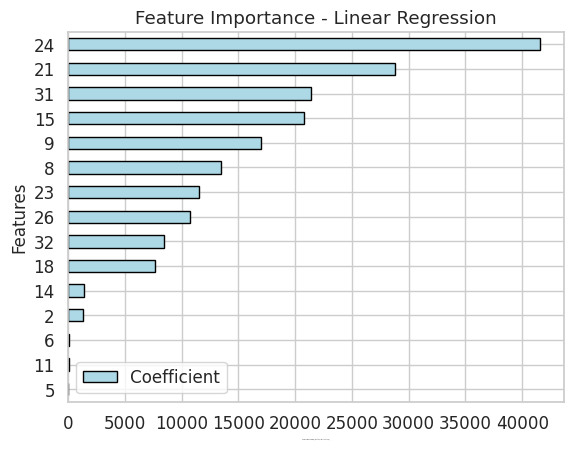

In [ ]:

feature_names = X_train.columns
coefficients = lr.coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance (sorted):")
print(importance_df.head(15))


plt.figure(figsize=(10,8))
importance_df.head(15).plot(kind='barh', color='lightblue', edgecolor='black')
#plt.barh(importance_df.head['Feature'], importance_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value (Feature Importance)', fontsize=1)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance - Linear Regression')
plt.gca().invert_yaxis()  # Highest at top
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train Linear Regression
lr = LinearRegression()

param_space = {'copy_X': [True,False], 'fit_intercept': [True,False],
               'n_jobs': [1,5,10,15,None], 'positive': [True,False]}
grid_search = GridSearchCV(lr, param_space, cv=5)

grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)



Best Parameters: {'copy_X': True, 'fit_intercept': False, 'n_jobs': 1, 'positive': True}
Best CV R² Score: 0.7484226509341269


In [ ]:
from xgboost import XGBRegressor

# Train XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    subsample=0.4

)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Regression Results:")
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)



XGBoost Regression Results:
RMSE: 83958.81047275504
R²: 0.5831490755081177


# Task 5 - Hyperparameter Tuning



In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
#from xgboost import XGBClassifier
# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500], #Num of trees
    'max_depth': [3, 5, 7], #Max depth of each tree
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.4, 0.5, 0.7, 0.9, 1.0] #fraction of samples used per tree
}

xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearch
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)


Fitting 3 folds for each of 135 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.5}
Best CV R² Score: 0.7154501477877299


Feature Importance of **XGBoost Model** (Which Features Affect Price Most)

Top features affecting SalePrice:


,0
GrLivArea,0.251750
Neighborhood_Somerst,0.122625
Remodeled,0.081114
YearRemodAdd,0.062112
Neighborhood_Veenker,0.037564
FullBath,0.036439
Heating_Gas,0.035255
YearBuilt,0.034388
PriceFactor,0.033879
GarageCars,0.033537


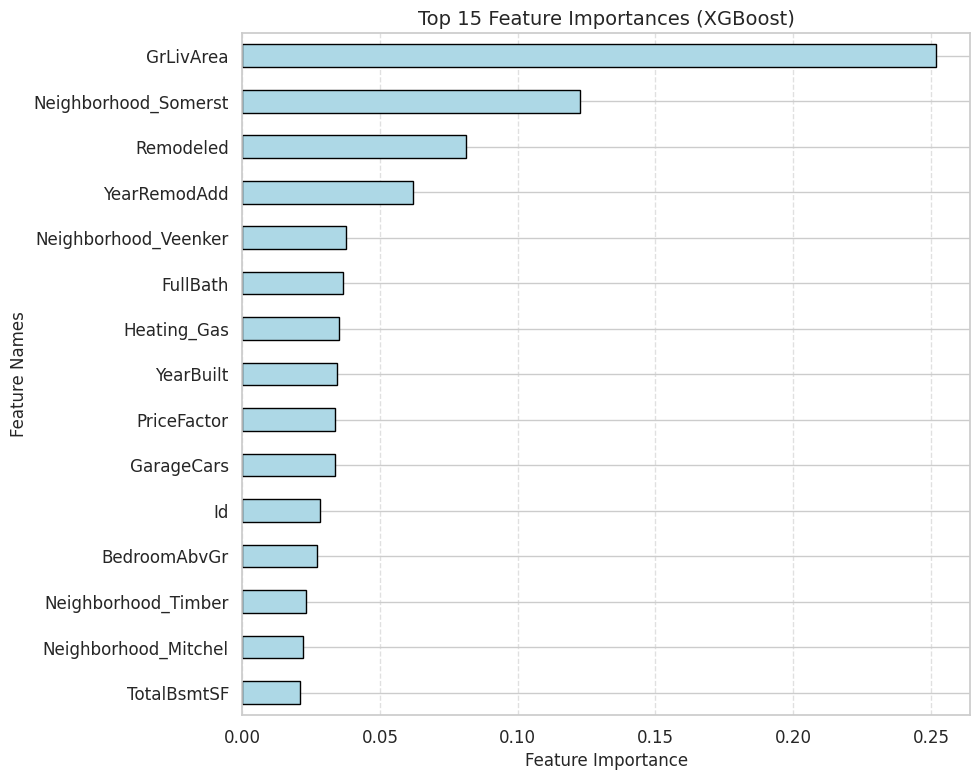

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    subsample=0.5

)
xgb.fit(X_train, y_train)


# Feature importances
feat_importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Display top 15 features
print("Top features affecting SalePrice:")
display(feat_importances.head(15))

# Plot
plt.figure(figsize=(10, 8))
feat_importances.head(15).plot(kind='barh', color='lightblue', edgecolor='black')
plt.title("Top 15 Feature Importances (XGBoost)", fontsize=14)
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Feature Names", fontsize=12)
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train Linear Regression
lr = LinearRegression()

param_space = {'copy_X': [True,False], 'fit_intercept': [True,False],
               'n_jobs': [1,5,10,15,None], 'positive': [True,False]}
grid_search = GridSearchCV(lr, param_space, cv=5)

grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)



ValueError: 
All the 200 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_base.py", line 601, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y(X, y, **check_

In [ ]:

feature_names = X_train.columns
coefficients = lr.coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance (sorted):")
print(importance_df.head(15))


plt.figure(figsize=(10,8))
importance_df.head(15).plot(kind='barh', color='lightblue', edgecolor='black')
#plt.barh(importance_df.head['Feature'], importance_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value (Feature Importance)', fontsize=1)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance - Linear Regression')
plt.gca().invert_yaxis()  # Highest at top
plt.show()
